In [3]:
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Step 1: Load the dataset
data = fetch_openml("adult", version=2, as_frame=True, parser='auto')
df = data.frame
X = df.drop(columns=["class"])
y = df["class"]

# Check for missing values
print("Dataset Info:\n", X.info())
# Check for missing values
missing_values = X.isnull().sum()
print("\nMising values in each column:")
print(X.isnull().sum())
#Check target distribution
print("Target distribution:\n", y.value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   age             48842 non-null  int64   
 1   workclass       46043 non-null  category
 2   fnlwgt          48842 non-null  int64   
 3   education       48842 non-null  category
 4   education-num   48842 non-null  int64   
 5   marital-status  48842 non-null  category
 6   occupation      46033 non-null  category
 7   relationship    48842 non-null  category
 8   race            48842 non-null  category
 9   sex             48842 non-null  category
 10  capital-gain    48842 non-null  int64   
 11  capital-loss    48842 non-null  int64   
 12  hours-per-week  48842 non-null  int64   
 13  native-country  47985 non-null  category
dtypes: category(8), int64(6)
memory usage: 2.6 MB
Dataset Info:
 None

Mising values in each column:
age                  0
workclass         2799
fnlwgt 

In [11]:
# Step 2: Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [12]:
# Step 3: Handle numerical features
num_features = X_train.select_dtypes(include=['number']).columns
X_train_num = X_train[num_features]
X_test_num = X_test[num_features]

In [13]:
# Step 4: Train a Decision Tree
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train_num, y_train)
train_acc = accuracy_score(y_train, clf.predict(X_train_num))
test_acc = accuracy_score(y_test, clf.predict(X_test_num))
print(f"Decision Tree - Train Accuracy: {train_acc}, Test Accuracy: {test_acc}")
print(f"Tree Depth: {clf.get_depth()}, Leaves: {clf.get_n_leaves()}")

Decision Tree - Train Accuracy: 0.9986691577304021, Test Accuracy: 0.7714197973180469
Tree Depth: 52, Leaves: 7857


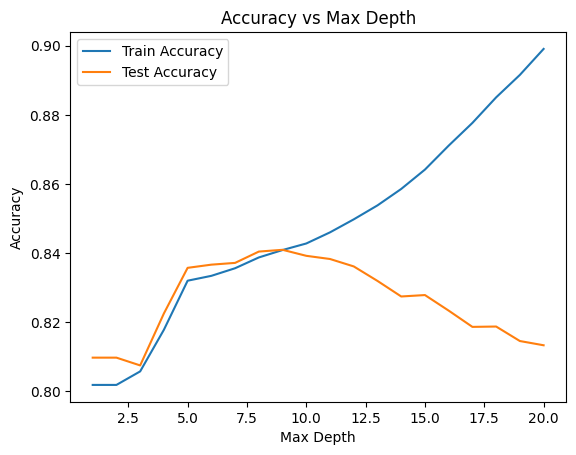

In [14]:
# Step 5: Accuracy vs Max Depth
depths = range(1, 21)
train_accuracies = []
test_accuracies = []
for depth in depths:
    clf = DecisionTreeClassifier(max_depth=depth, random_state=42)
    clf.fit(X_train_num, y_train)
    train_accuracies.append(accuracy_score(y_train, clf.predict(X_train_num)))
    test_accuracies.append(accuracy_score(y_test, clf.predict(X_test_num)))

plt.plot(depths, train_accuracies, label='Train Accuracy')
plt.plot(depths, test_accuracies, label='Test Accuracy')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy vs Max Depth')
plt.show()

In [15]:
# Step 6: Cross-validation and GridSearchCV
param_grid = {
    'max_depth': [3, 5, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=3, scoring='accuracy')
grid_search.fit(X_train_num, y_train)
print(f"Best parameters: {grid_search.best_params_}")


Best parameters: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10}


In [16]:
# Step 7: Handle Categorical Features
cat_features = X_train.select_dtypes(include=['object']).columns
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

In [8]:
# Step 8: Combined Pipeline
preprocessor = ColumnTransformer([
    ('num', 'passthrough', num_features),
    ('cat', cat_pipeline, cat_features)
])
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42))
])
pipeline.fit(X_train, y_train)
print(f"Pipeline Train Accuracy: {accuracy_score(y_train, pipeline.predict(X_train))}")
print(f"Pipeline Test Accuracy: {accuracy_score(y_test, pipeline.predict(X_test))}")


Pipeline Train Accuracy: 0.9986691577304021
Pipeline Test Accuracy: 0.7714197973180469


In [9]:
# Step 9-14: Train Ensemble Models
ensemble_models = {
    'Random Forest': RandomForestClassifier(random_state=42),
    'AdaBoost': AdaBoostClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

for name, model in ensemble_models.items():
    model_pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    model_pipeline.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, model_pipeline.predict(X_train))
    test_acc = accuracy_score(y_test, model_pipeline.predict(X_test))
    print(f"{name} - Train Accuracy: {train_acc}, Test Accuracy: {test_acc}")


Random Forest - Train Accuracy: 0.9985923783686945, Test Accuracy: 0.8085781553894974
AdaBoost - Train Accuracy: 0.8337982750236737, Test Accuracy: 0.8375473436380387
Gradient Boosting - Train Accuracy: 0.8414506180738618, Test Accuracy: 0.8439963148735797
